In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,MultiLabelBinarizer,StandardScaler

In [7]:
import pandas as pd

df = pd.DataFrame({
    'sensor_id':  ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8'],
    'location':   ['Roof', 'Basement', 'Roof', 'Floor2', 'Basement', 'Floor2', 'Roof', 'Floor2'],
    'risk_level': ['Low', 'Critical', 'Medium', 'Low', 'High', 'Critical', 'Medium', 'High'],
    'status':     ['Active', 'Inactive', 'Active', 'Active', 'Inactive', 'Active', 'Inactive', 'Active'],
    'temp_c':     [22.5, 18.0, 35.2, 21.8, 19.4, 40.1, 23.0, 20.6],
    'humidity':   [45, 78, 32, 51, 82, 28, 47, 55],
    'uptime_hrs': [8760, 120, 4380, 15, 8000, 90, 6200, 45]
})

In [8]:
#Ordinal encode risk_level with order Low < Medium < High < Critical.
unique_risk_level = 'Low < Medium < High < Critical'.split(' < ')
risk_level_mapping = {k:i for i,k in enumerate(unique_risk_level)}
df['risk_level'] = df['risk_level'].map(risk_level_mapping)
df

,sensor_id,location,risk_level,status,temp_c,humidity,uptime_hrs
0,S1,Roof,0,Active,22.5,45,8760
1,S2,Basement,3,Inactive,18.0,78,120
2,S3,Roof,1,Active,35.2,32,4380
3,S4,Floor2,0,Active,21.8,51,15
4,S5,Basement,2,Inactive,19.4,82,8000
5,S6,Floor2,3,Active,40.1,28,90
6,S7,Roof,1,Inactive,23.0,47,6200
7,S8,Floor2,2,Active,20.6,55,45


In [11]:
#One-hot location with drop_first=True. Drop the original column.
df = pd.get_dummies(df,columns=['location'],drop_first=True)
df

,sensor_id,risk_level,status,temp_c,humidity,uptime_hrs,location_Floor2,location_Roof
0,S1,0,Active,22.5,45,8760,False,True
1,S2,3,Inactive,18.0,78,120,False,False
2,S3,1,Active,35.2,32,4380,False,True
3,S4,0,Active,21.8,51,15,True,False
4,S5,2,Inactive,19.4,82,8000,False,False
5,S6,3,Active,40.1,28,90,True,False
6,S7,1,Inactive,23.0,47,6200,False,True
7,S8,2,Active,20.6,55,45,True,False


In [12]:
#Label encode status. Print the mapping and say in one line why label encoding is defensible here but was not for plan earlier.
lbl = LabelEncoder()
df['status'] = lbl.fit_transform(df['status'])
df

,sensor_id,risk_level,status,temp_c,humidity,uptime_hrs,location_Floor2,location_Roof
0,S1,0,0,22.5,45,8760,False,True
1,S2,3,1,18.0,78,120,False,False
2,S3,1,0,35.2,32,4380,False,True
3,S4,0,0,21.8,51,15,True,False
4,S5,2,1,19.4,82,8000,False,False
5,S6,3,0,40.1,28,90,True,False
6,S7,1,1,23.0,47,6200,False,True
7,S8,2,0,20.6,55,45,True,False


In [13]:
#Min-max scale humidity manually, then again with MinMaxScaler. Compare with np.allclose.
humidity_min = df['humidity'].min()
humidity_max = df['humidity'].max()
df['humidity'] = (df['humidity'] - humidity_min)/(humidity_max-humidity_min)
df

,sensor_id,risk_level,status,temp_c,humidity,uptime_hrs,location_Floor2,location_Roof
0,S1,0,0,22.5,0.314815,8760,False,True
1,S2,3,1,18.0,0.925926,120,False,False
2,S3,1,0,35.2,0.074074,4380,False,True
3,S4,0,0,21.8,0.425926,15,True,False
4,S5,2,1,19.4,1.000000,8000,False,False
5,S6,3,0,40.1,0.000000,90,True,False
6,S7,1,1,23.0,0.351852,6200,False,True
7,S8,2,0,20.6,0.500000,45,True,False


In [16]:
from sklearn.preprocessing import MinMaxScaler
df2 = pd.DataFrame({
    'sensor_id':  ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8'],
    'location':   ['Roof', 'Basement', 'Roof', 'Floor2', 'Basement', 'Floor2', 'Roof', 'Floor2'],
    'risk_level': ['Low', 'Critical', 'Medium', 'Low', 'High', 'Critical', 'Medium', 'High'],
    'status':     ['Active', 'Inactive', 'Active', 'Active', 'Inactive', 'Active', 'Inactive', 'Active'],
    'temp_c':     [22.5, 18.0, 35.2, 21.8, 19.4, 40.1, 23.0, 20.6],
    'humidity':   [45, 78, 32, 51, 82, 28, 47, 55],
    'uptime_hrs': [8760, 120, 4380, 15, 8000, 90, 6200, 45]
})
minmax = MinMaxScaler()
df2['humidity'] = minmax.fit_transform(df2[['humidity']])
np.allclose(df['humidity'].values, df2['humidity'].values)

True

In [17]:
#Standardise temp_c manually using ddof=0, then with StandardScaler. Compare with np.allclose.
temp_mean = np.mean(df['temp_c'])
temp_std = np.std(df['temp_c'])
df['temp_c'] = (df['temp_c']-temp_mean)/temp_std
df

,sensor_id,risk_level,status,temp_c,humidity,uptime_hrs,location_Floor2,location_Roof
0,S1,0,0,-0.342491,0.314815,8760,False,True
1,S2,3,1,-0.941020,0.925926,120,False,False
2,S3,1,0,1.346690,0.074074,4380,False,True
3,S4,0,0,-0.435596,0.425926,15,True,False
4,S5,2,1,-0.754811,1.000000,8000,False,False
5,S6,3,0,1.998421,0.000000,90,True,False
6,S7,1,1,-0.275988,0.351852,6200,False,True
7,S8,2,0,-0.595204,0.500000,45,True,False


In [24]:
std_scaler = StandardScaler()
df2['temp_c'] = std_scaler.fit_transform(df[['temp_c']])
np.allclose(df['temp_c'].values, df2['temp_c'].values)

True

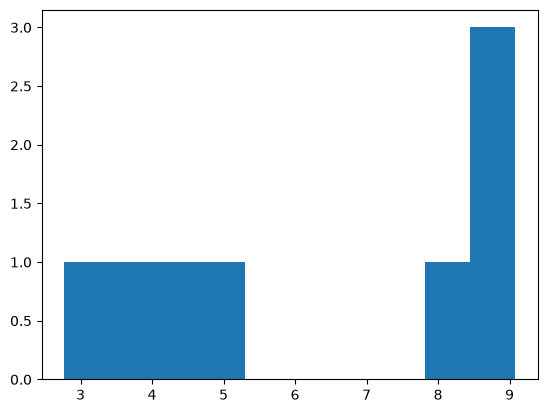

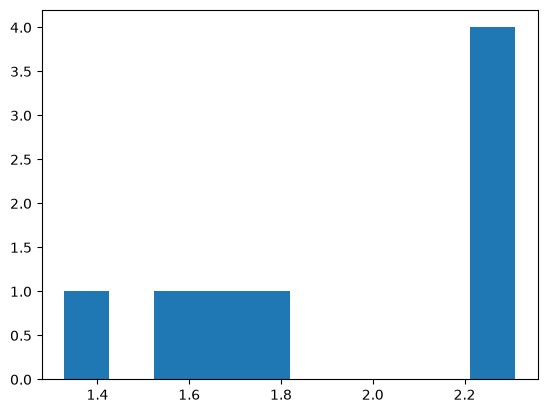

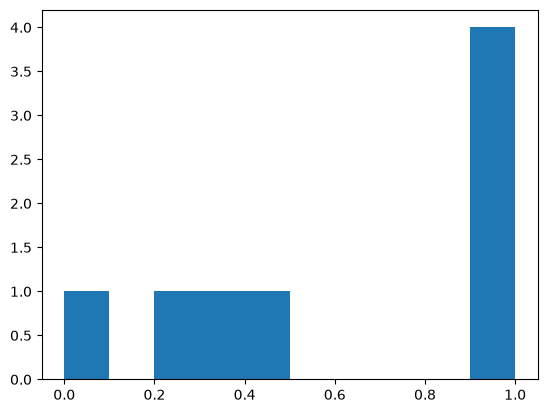

In [30]:
#uptime_hrs spans 15 to 8760. Plot its histogram, apply np.log1p, plot again. Then min-max scale the logged version.
plt.hist(df['uptime_hrs'])
plt.show()
df['uptime_hrs'] = np.log1p(df['uptime_hrs'])
plt.hist(df['uptime_hrs'])
plt.show()
df['uptime_hrs'] = minmax.fit_transform(df[['uptime_hrs']])
plt.hist(df['uptime_hrs'])
plt.show()